In [1]:
import pandas as pd
import numpy as np

import sqlite3

import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA

In [7]:
import sqlite3

conn = sqlite3.connect(r"C:\SRH DOC\Niriksha\supplychain.db")

In [8]:
query = """
SELECT *
FROM clean_supply_chain
"""

df = pd.read_sql(query, conn)

df.head()

,Order ID,Order Date,Product ID,Product Category,Supplier,Warehouse,Inventory Quantity,Reorder Level,Lead Time,Transportation Cost,Delivery Date,Delivery Delay (Days),Sales Quantity,Sales Revenue,Customer Region,Customer ID,Order Status,Purchase Cost,Profit Margin,Profit
0,ORD-101700,2023-01-01 10:54:29,PRD-0047,Packaging Materials,Supplier-10,WH-Central,804,485,11,271.60,2023-01-12 10:54:29,0,32,21158.05,Middle East & Africa,CUST-00905,Delivered,13719.97,0.351548,7438.08
1,ORD-105576,2023-01-01 13:37:57,PRD-0002,Packaging Materials,Supplier-16,WH-South,160,131,12,143.27,2023-01-13 13:37:57,0,7,1683.87,Asia Pacific,CUST-00468,Delivered,1380.62,0.180091,303.25
2,ORD-100094,2023-01-01 13:37:57,PRD-0054,Electronics,Supplier-10,WH-South,578,337,11,246.96,2023-01-12 13:37:57,0,18,8643.78,North America,CUST-00515,Delivered,6025.23,0.302940,2618.55
3,ORD-102353,2023-01-01 16:52:47,PRD-0007,Automotive Parts,Supplier-05,WH-East,483,339,27,575.49,2023-01-28 16:52:47,0,24,6660.20,Latin America,CUST-00692,Delivered,4964.39,0.254618,1695.81
4,ORD-103455,2023-01-01 16:52:47,PRD-0053,Consumer Goods,Supplier-18,WH-West,414,358,25,265.78,2023-01-26 16:52:47,0,18,3757.59,Middle East & Africa,CUST-00594,Delivered,2448.36,0.348423,1309.23


In [9]:
df.columns

Index(['Order ID', 'Order Date', 'Product ID', 'Product Category', 'Supplier',
       'Warehouse', 'Inventory Quantity', 'Reorder Level', 'Lead Time',
       'Transportation Cost', 'Delivery Date', 'Delivery Delay (Days)',
       'Sales Quantity', 'Sales Revenue', 'Customer Region', 'Customer ID',
       'Order Status', 'Purchase Cost', 'Profit Margin', 'Profit'],
      dtype='str')

In [10]:
df["Delivery Date"] = pd.to_datetime(df["Delivery Date"])

In [11]:
monthly_demand = (
    df.groupby(
        df["Delivery Date"].dt.to_period("M")
    )["Sales Quantity"]
    .sum()
)

In [12]:
monthly_demand.index = monthly_demand.index.to_timestamp()

In [13]:
monthly_demand

Delivery Date
2023-01-01    1481
2023-02-01    2805
2023-03-01    4022
2023-04-01    3684
2023-05-01    4001
2023-06-01    4630
2023-07-01    3953
2023-08-01    3621
2023-09-01    3607
2023-10-01    5593
2023-11-01    6208
2023-12-01    6484
2024-01-01    5099
2024-02-01    3037
2024-03-01    3695
2024-04-01    4653
2024-05-01    4803
2024-06-01    4806
2024-07-01    3796
2024-08-01    4136
2024-09-01    4583
2024-10-01    4989
2024-11-01    5959
2024-12-01    5774
2025-01-01    4441
2025-02-01    3155
2025-03-01    4196
2025-04-01    3939
2025-05-01    4706
2025-06-01    4611
2025-07-01    4320
2025-08-01    4181
2025-09-01    3871
2025-10-01    5395
2025-11-01    4692
2025-12-01    4736
2026-01-01    3354
Freq: MS, Name: Sales Quantity, dtype: int64

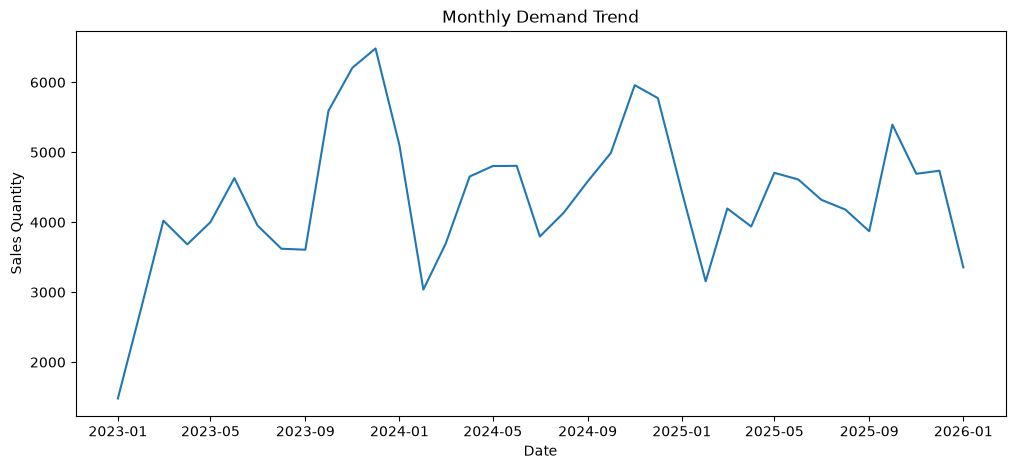

In [14]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_demand.index,
    monthly_demand.values
)

plt.title("Monthly Demand Trend")
plt.xlabel("Date")
plt.ylabel("Sales Quantity")

plt.show()

In [15]:
train = monthly_demand[:-3]

test = monthly_demand[-3:]

In [16]:
model = ARIMA(
    train,
    order=(1,1,1)
)

In [17]:
model_fit = model.fit()


In [18]:
forecast = model_fit.forecast(
    steps=3
)

forecast

2025-11-01    5225.286231
2025-12-01    5100.080183
2026-01-01    5007.709630
Freq: MS, Name: predicted_mean, dtype: float64

In [19]:
forecast_df = pd.DataFrame(
    {
        "Month": forecast.index,
        "Forecast_Demand": forecast.values
    }
)

forecast_df

,Month,Forecast_Demand
0,2025-11-01,5225.286231
1,2025-12-01,5100.080183
2,2026-01-01,5007.709630


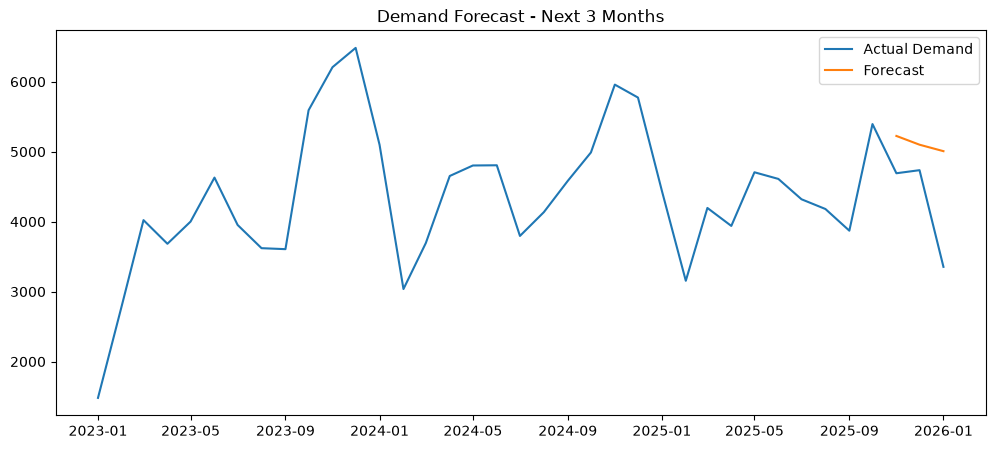

In [20]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_demand,
    label="Actual Demand"
)

plt.plot(
    forecast,
    label="Forecast"
)

plt.legend()

plt.title(
    "Demand Forecast - Next 3 Months"
)

plt.show()

In [ ]:
forecast_df.head()
len(forecast_df)